# Model Comparison - Heart Disease

Compares all eight tuned model families on the **validation** set, selects the
best by ROC-AUC (recall as tie-breaker), refits it on **train + validation**,
and evaluates it **once** on the **test** set.

**This is the only notebook that touches the test set.** The per-model
notebooks stop at validation so the hold-out is spent exactly once, here.
Estimators and grids come from the `MODELS` registry in `train_models.py`, and
the CV splitter is seeded, so the validation numbers should match
`models/comparison.csv` from the batch script.

In [1]:
import sys
from pathlib import Path

# Make the scripts/ helpers importable from notebooks/.
sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, roc_curve, ConfusionMatrixDisplay

from dataset import load_splits, get_xy
from train_models import build_pipeline, evaluate, MODELS, CV

## Load data

In [2]:
train, val, test = load_splits()
X_train, y_train = get_xy(train)
X_val, y_val = get_xy(val)
X_test, y_test = get_xy(test)

print(f"train {X_train.shape}  val {X_val.shape}  test {X_test.shape}")
print(f"disease rate  train {y_train.mean():.3f}  val {y_val.mean():.3f}  test {y_test.mean():.3f}")

train (552, 15)  val (184, 15)  test (184, 15)
disease rate  train 0.553  val 0.554  test 0.554


## Tune all models (train, 5-fold CV)

Each family is tuned exactly as in its own notebook: stratified 5-fold
`GridSearchCV` on the training set, scoring ROC-AUC. The tuned pipelines are
kept for the validation comparison below.

In [3]:
results = []
tuned = {}
for name, cfg in MODELS.items():
    pipe = build_pipeline(cfg["estimator"], cfg["needs_scaling"], list(X_train.columns))
    search = GridSearchCV(pipe, cfg["grid"], cv=CV, scoring="roc_auc", n_jobs=-1)
    search.fit(X_train, y_train)

    tuned[name] = search.best_estimator_
    row = evaluate(search.best_estimator_, X_val, y_val)
    row.update(model=name, cv_roc_auc=search.best_score_)
    results.append(row)
    print(f"{name:24s} cv_auc={search.best_score_:.3f}  "
          f"val_auc={row['roc_auc']:.3f}  val_recall={row['recall']:.3f}")

logreg                   cv_auc=0.867  val_auc=0.865  val_recall=0.853
svm                      cv_auc=0.865  val_auc=0.865  val_recall=0.873
knn                      cv_auc=0.863  val_auc=0.859  val_recall=0.863
decision_tree            cv_auc=0.805  val_auc=0.807  val_recall=0.794
random_forest            cv_auc=0.867  val_auc=0.868  val_recall=0.902
gradient_boosting        cv_auc=0.861  val_auc=0.856  val_recall=0.873
hist_gradient_boosting   cv_auc=0.850  val_auc=0.852  val_recall=0.873
naive_bayes              cv_auc=0.871  val_auc=0.859  val_recall=0.833


## Validation comparison

Sorted by validation ROC-AUC (the primary metric). Recall matters most
clinically - a missed diagnosis is the costly error - so it is shown alongside
and used as the tie-breaker.

In [4]:
comparison = pd.DataFrame(results).set_index("model")
comparison = comparison[
    ["cv_roc_auc", "roc_auc", "recall", "precision", "f1", "accuracy"]
].sort_values("roc_auc", ascending=False)
comparison.round(3)

,cv_roc_auc,roc_auc,recall,precision,f1,accuracy
model,,,,,,
random_forest,0.867,0.868,0.902,0.793,0.844,0.815
svm,0.865,0.865,0.873,0.795,0.832,0.804
logreg,0.867,0.865,0.853,0.798,0.825,0.799
knn,0.863,0.859,0.863,0.807,0.834,0.810
naive_bayes,0.871,0.859,0.833,0.794,0.813,0.788
gradient_boosting,0.861,0.856,0.873,0.767,0.817,0.783
hist_gradient_boosting,0.850,0.852,0.873,0.754,0.809,0.772
decision_tree,0.805,0.807,0.794,0.764,0.779,0.750


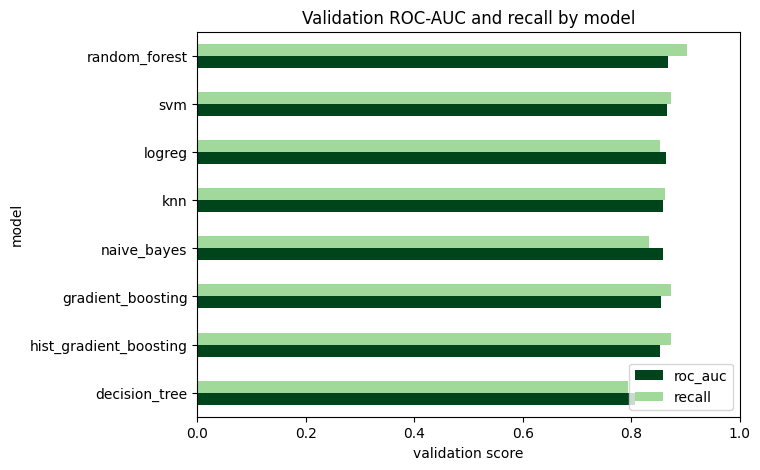

In [5]:
comparison[["roc_auc", "recall"]].iloc[::-1].plot(
    kind="barh", color={"roc_auc": "#00441b", "recall": "#a1d99b"}, figsize=(7, 5)
)
plt.xlim(0, 1)
plt.xlabel("validation score")
plt.title("Validation ROC-AUC and recall by model")
plt.legend(loc="lower right")
plt.show()

## Validation ROC curves

All eight tuned models on the same axes, ordered by AUC. The curves bunch
together - on 184 validation rows the families are hard to separate, which is
why the selection rule (AUC, then recall) is fixed in advance.

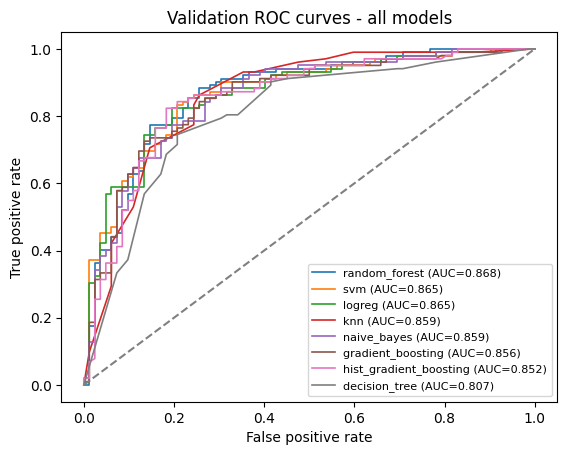

In [6]:
for name in comparison.index:
    p = tuned[name].predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, p)
    plt.plot(fpr, tpr, lw=1.2, label=f"{name} (AUC={comparison.loc[name, 'roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], ls="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Validation ROC curves - all models")
plt.legend(fontsize=8)
plt.show()

## Select and refit

Best by validation ROC-AUC, recall as tie-breaker. The winner is cloned and
refit on train + validation (the tuned hyperparameters are kept; `clone` keeps
the validation-fitted pipeline in `tuned` intact), so the final model sees all
736 non-test rows before its single test evaluation.

In [7]:
best_name = comparison.sort_values(["roc_auc", "recall"], ascending=False).index[0]

X_trainval = pd.concat([X_train, X_val], ignore_index=True)
y_trainval = pd.concat([y_train, y_val], ignore_index=True)
final_model = clone(tuned[best_name]).fit(X_trainval, y_trainval)

print(f"selected: {best_name}")
print(f"refit on train+val: {X_trainval.shape[0]} rows")

selected: random_forest
refit on train+val: 736 rows


## Final test evaluation

The one and only look at the test set in the whole project. Some drop from the
validation numbers is expected: the model was *selected* on validation, so its
validation score is optimistically biased; the test score is the honest
estimate.

In [8]:
test_metrics = evaluate(final_model, X_test, y_test)
pd.Series(test_metrics, name=f"{best_name} (test)").round(3)

roc_auc      0.907
recall       0.863
precision    0.793
f1           0.826
accuracy     0.799
Name: random_forest (test), dtype: float64

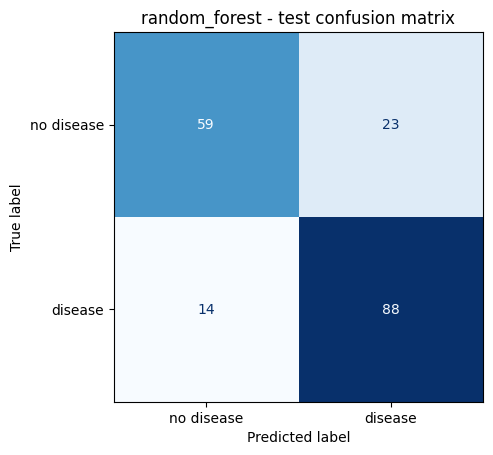

In [9]:
test_pred = final_model.predict(X_test)
ConfusionMatrixDisplay(
    confusion_matrix(y_test, test_pred), display_labels=["no disease", "disease"]
).plot(cmap="Blues", colorbar=False)
plt.title(f"{best_name} - test confusion matrix")
plt.show()

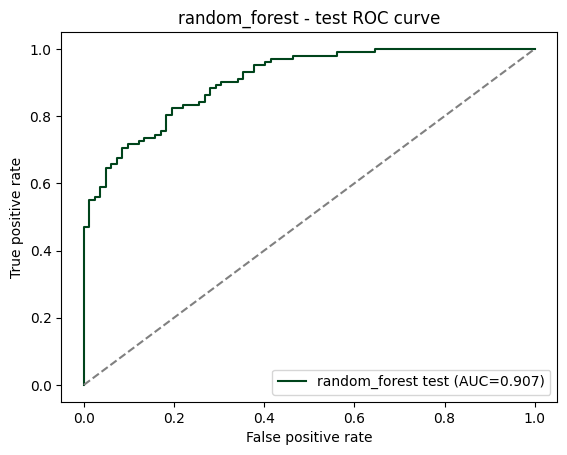

In [10]:
test_proba = final_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, test_proba)
plt.plot(fpr, tpr, color="#00441b",
         label=f"{best_name} test (AUC={test_metrics['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], ls="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title(f"{best_name} - test ROC curve")
plt.legend()
plt.show()

## Notes

- The test set is spent here, once. Re-running model selection after seeing
  these numbers would turn the test set into a second validation set.
- `clone` before the refit keeps `tuned[best_name]` fitted on train only, so
  re-running the validation cells above stays honest.
- The validation table should match `models/comparison.csv` from
  `scripts/train_models.py` - same registry, pipelines, and seeded CV splits.
- With 184-row validation and test sets, differences of a few hundredths of
  AUC between families are within noise; the fixed selection rule exists so
  that noise is not cherry-picked.